# Tier 10c: Halo-class two-rotor series-hybrid sizing

One explicit `asb.Opti` (`examples/halo_sizing.py`) sizes a two-rotor
tiltrotor. The aircraft has two turbogenerators and a battery on one bus, and
the optimizer chooses its 445 nm mission and the battery/generator split at
the same time. It reuses the Tier 9 formulation, re-baselined on the Bell
XV-15:

- **weights:** Raymer GA airframe x the XV-15 calibration factors (Tier 10a),
  with AFDD82 rotors, AFDD83 gearboxes and the AFDD82 engine section;
- **turboshafts:** mass from the AeroSandbox regression, as an explicit
  equality; thermal efficiency from the same regression;
- **engine behaviour:** lapse sigma^0.80 and part-power knockdown (Tier 10b);
- **hover:** figure of merit 0.67 with 7 % download (Tier 10b).

**Requirements** (user-approved 2026-10-02):

- 900 kg payload;
- 445 nm mission with a 20-minute reserve and 10 % fuel margin;
- 250 kt at 10,000 ft;
- 13,000 ft ceiling;
- OGE hover at 4,000 ft with T/W 1.05;
- 60 s of engine-out hover on one turbogenerator plus the battery;
- stall at or below 120 kt.

**Geometry:** the rotors sit at the wing tips and must clear the fuselage, so
R <= (b - fuselage width) / 2 - 0.3 m.

Plan 013 lists every assumption.

```powershell
uv run jupyter lab notebooks/tier10_halo_sizing
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt
from aerosandbox.library.power_turboshaft import power_turboshaft

from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier11a, requirements_tier10c,
                                  soc_emergency_floor, soc_minimum, solve_halo_sizing)
from examples.xv15_reference import Xv15MassFactors, calibration_factors

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})
# This notebook records Tier 10c-11a (sized engines, 250 kt, actuator-disk rotor, deck part-power curve).
req, ass = requirements_tier10c, assumptions_tier11a

# Plan 022 made the 780 kg equivalent-circuit pack the reference; this notebook keeps reproducing its own tier
# (900 kg, constant-OCV battery).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
from examples.halo_sizing import solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, battery_model="constant", wing_weight_model="raymer",
                          aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=900.0)
solve_halo_sizing = partial(_solve_halo_sizing, requirements=HaloRequirements(), assumptions=HaloAssumptions())


## 1. The reference design

In [2]:
r = solve_halo_sizing(requirements=req, assumptions=ass)
d = r.design
print(f"take-off {r.mass_takeoff_kg:,.0f} kg = {r.mass_takeoff_kg / u.lbm:,.0f} lb; empty {r.mass_empty_kg / u.lbm:,.0f} lb; "
      f"fuel {r.mass_fuel_kg / u.lbm:,.0f} lb; battery {r.energy_battery_kWh:.0f} kWh / {d.power_max_discharge_battery_W / 1e3:,.0f} kW")
print(f"wing {d.area_wing_m2:.1f} m2, span {r.span_m:.2f} m, W/S {r.wing_loading_kg_m2:.0f} kg/m2; rotor diameter "
      f"{2 * r.radius_rotor_m / u.foot:.1f} ft, DL {r.disk_loading_kg_m2:.0f} kg/m2")
print(f"motors 2 x {r.power_rated_motor_W / 1e3:,.0f} kW; turboshafts 2 x {d.power_rated_turboshaft_W / 1e3:,.0f} kW "
      f"({d.mass_turboshaft_bare_kg:.0f} kg bare, thermal efficiency {r.thermal_efficiency_turboshaft:.3f})")
print(f"cruise {r.velocity_cruise_m_s / u.knot:.0f} kt at 10,000 ft, L/D {r.lift_to_drag_cruise:.1f}, CL {r.cl_cruise:.2f}; "
      f"loiter {r.velocity_loiter_m_s / u.knot:.0f} kt")
print("binding:", ", ".join(r.binding))
check("every constraint satisfied", r.min_margin > -1e-6)
check("mass closure residual below 1e-5 kg", abs(r.closure_residual_kg) < 1e-5)
check("turboshaft on the AeroSandbox mass-power regression",
      abs(float(power_turboshaft(d.mass_turboshaft_bare_kg)) / d.power_rated_turboshaft_W - 1) < 1e-6)
check("rotor fits between fuselage and wing tip",
      r.radius_rotor_m <= (r.span_m - ass.diameter_fuselage_m) / 2 - ass.clearance_rotor_fuselage_m + 1e-6)
check("landing SOC at the 0.30 floor or above", r.soc_end >= soc_minimum - 1e-6)
check("engine-out reserve leaves SOC >= 0.10", r.soc_after_engine_out >= soc_emergency_floor - 1e-6)
check("Halo-class weight: 1x,xxx lb", 10000 < r.mass_takeoff_kg / u.lbm < 20000)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


take-off 8,394 kg = 18,506 lb; empty 13,843 lb; fuel 2,679 lb; battery 138 kWh / 1,635 kW
wing 23.5 m2, span 12.00 m, W/S 357 kg/m2; rotor diameter 27.3 ft, DL 77 kg/m2
motors 2 x 1,419 kW; turboshafts 2 x 1,274 kW (277 kg bare, thermal efficiency 0.282)
cruise 178 kt at 10,000 ft, L/D 8.3, CL 0.92; loiter 131 kt
binding: max_speed: turboshaft power_shaft_W, hover: motor power_shaft_W, hover: gearbox power_input_W, hover: propulsor power_shaft_W, engine-out hover: generator power_shaft_W, stall_lift_at_120kt, max_speed: generator power_shaft_W, engine-out hover: battery discharge_power_W, soc_after_engine_out_hover, static_margin, cn_beta_per_rad, soc_end, take-off hover: generator power_shaft_W
PASS  every constraint satisfied
PASS  mass closure residual below 1e-5 kg
PASS  turboshaft on the AeroSandbox mass-power regression
PASS  rotor fits between fuselage and wing tip
PASS  landing SOC at the 0.30 floor or above
PASS  engine-out reserve leaves SOC >= 0.10
PASS  Halo-class weight: 1

**Reading the binding list.** Each limit sizes one part:

- **Max speed (250 kt at 10,000 ft)** sizes the turboshafts and generators.
- **Hover at 4,000 ft** sizes the motors, gearboxes and rotors.
- **Engine-out hover on one turbogenerator** sizes the battery's discharge
  power. Its energy follows from that power rating, and the mission spends
  the energy down to the 0.30 floor.
- **The 120 kt stall limit** sizes the wing.
- **Static margin and Cn_beta** size the tails.

The rotor-span clearance is not active: the stall-sized wing is wide enough
for the rotors hover wants.

PASS  empty groups sum to empty mass


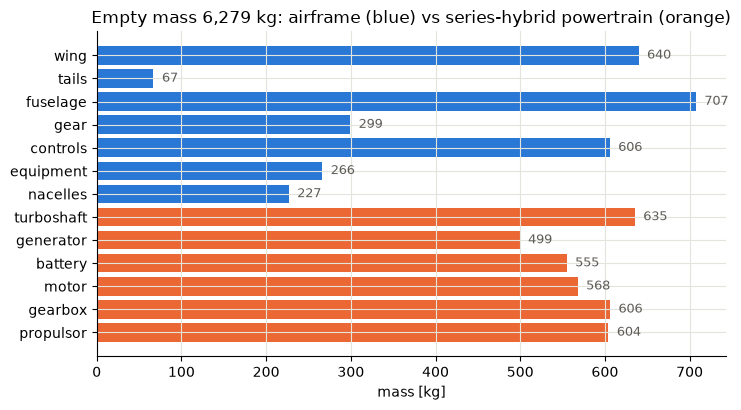

powertrain share of empty mass: 55%


In [3]:
masses = dict(r.component_masses_kg)
powertrain = dict(r.powertrain_masses_kg)
empty = {"wing": masses["wing"], "tails": masses["horizontal_tail"] + masses["vertical_tail"],
         "fuselage": masses["fuselage"], "gear": masses["landing_gear"], "controls": masses["systems"],
         "equipment": masses["equipment"], "nacelles": masses["nacelles"], **powertrain}
check("empty groups sum to empty mass", abs(sum(empty.values()) - r.mass_empty_kg) < 1e-6)
names = list(empty)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(names, [empty[n] for n in names], color=[orange if n in powertrain else blue for n in names])
ax.invert_yaxis()
ax.set(xlabel="mass [kg]", title=f"Empty mass {r.mass_empty_kg:,.0f} kg: airframe (blue) vs series-hybrid powertrain (orange)")
for i, n in enumerate(names):
    ax.text(empty[n] + 10, i, f"{empty[n]:,.0f}", va="center", fontsize=9, color=ink_muted)
plt.tight_layout()
plt.show()
print(f"powertrain share of empty mass: {sum(powertrain.values()) / r.mass_empty_kg:.0%}")

## 2. Mission and energy allocation

  take-off hover    1.0 min    10.5 kg fuel  SOC 0.867  battery share 0.26    2411 kW
  climb             8.5 min    75.4 kg fuel  SOC 0.867  battery share -0.00    1499 kW
  cruise          133.8 min   886.3 kg fuel  SOC 0.867  battery share -0.00    1039 kW
  reserve loiter   20.0 min   112.0 kg fuel  SOC 0.867  battery share -0.00     786 kW
  descent          10.2 min    11.2 kg fuel  SOC 0.358  battery share 1.00     379 kW
  landing hover     1.0 min     9.2 kg fuel  SOC 0.300  battery share 0.23    1955 kW
PASS  battery shares within [0, 1]
PASS  fuel load is 1.1 x fuel burnt


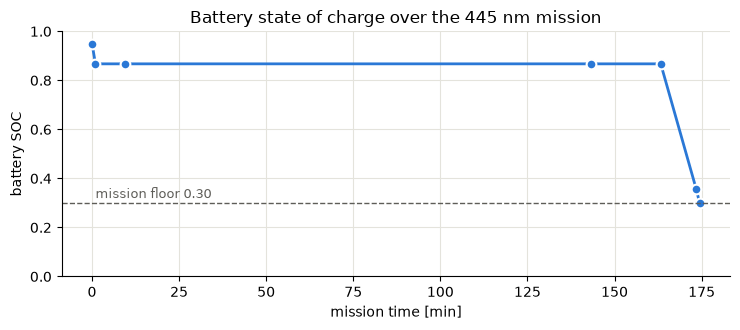

In [4]:
for s in r.segments:
    print(f"  {s['label']:<15}{s['duration_s'] / 60:6.1f} min {s['fuel_kg']:7.1f} kg fuel  SOC {s['soc_end']:.3f}  "
          f"battery share {s['hybridization']:.2f}  {s['power_rotors_W'] / 1e3:6.0f} kW")
check("battery shares within [0, 1]", all(-1e-6 <= s["hybridization"] <= 1 + 1e-6 for s in r.segments))
check("fuel load is 1.1 x fuel burnt", abs(r.mass_fuel_kg - 1.1 * r.mass_fuel_burnt_kg) < 1e-4)
t = np.cumsum([0] + [s["duration_s"] / 60 for s in r.segments])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(t, [0.95] + [s["soc_end"] for s in r.segments], color=blue, lw=2, marker="o", ms=7, mec="white", mew=1.5)
ax.axhline(soc_minimum, color=ink_muted, lw=1, ls="--")
ax.text(1, soc_minimum + 0.02, "mission floor 0.30", color=ink_muted, fontsize=9)
ax.set(xlabel="mission time [min]", ylabel="battery SOC", ylim=(0, 1), title="Battery state of charge over the 445 nm mission")
plt.tight_layout()
plt.show()

## 3. Sensitivities

Each case re-solves the whole coupled problem, warm-started from the
reference. A warm start is needed for the two larger perturbations; from the
default cold guess, IPOPT stops at a local infeasibility. Neither problem is
actually infeasible: nearby values such as a cruise coefficient of 0.82 or
0.84 solve from the cold guess, and both cases solve when warm-started.

reference                            18,506 lb
hover FM 0.75 (actuator disk)        17,259 lb (-6.7%)
cruise rotor coefficient 0.80 (actuator disk)   19,676 lb (+6.3%)
payload 600 kg                       16,513 lb (-10.8%)
payload 1,200 kg                     20,526 lb (+10.9%)
uncalibrated (Raymer GA) weights     13,357 lb (-27.8%)
PASS  better hover figure of merit lowers take-off weight (actuator disk)
PASS  worse cruise rotor raises take-off weight (actuator disk)
PASS  payload growth raises take-off weight
PASS  XV-15 calibration adds weight
growth factor d(MTOM)/d(payload) = 3.03


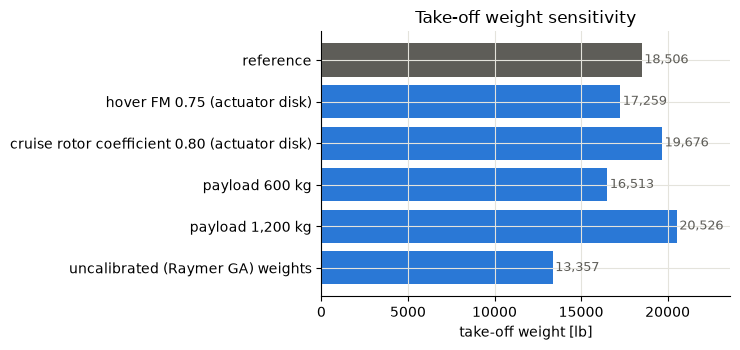

In [5]:
# Since Tier 12 the reference rotor is the JVX-calibrated MomentumProfileRotor; the FM / cruise-coefficient
# sensitivities apply to the actuator-disk option and are compared with its own baseline.
disk = replace(ass, rotor_speed_physics=False)
disk_baseline = solve_halo_sizing(requirements=req, assumptions=disk)
cases = [("hover FM 0.75 (actuator disk)", dict(assumptions=replace(disk, figure_of_merit=0.75))),
         ("cruise rotor coefficient 0.80 (actuator disk)", dict(assumptions=replace(disk, coefficient_airplane=0.80))),
         ("payload 600 kg", dict(requirements=replace(req, mass_payload_kg=600.0))),
         ("payload 1,200 kg", dict(requirements=replace(req, mass_payload_kg=1200.0))),
         ("uncalibrated (Raymer GA) weights", dict(factors=Xv15MassFactors()))]
results = {label: solve_halo_sizing(initial=disk_baseline if "actuator" in label else r,
                                   **{"requirements": req, "assumptions": ass, **kwargs})
           for label, kwargs in cases}
print(f"{'reference':<34}{r.mass_takeoff_kg / u.lbm:9,.0f} lb")
for label, case in results.items():
    print(f"{label:<34}{case.mass_takeoff_kg / u.lbm:9,.0f} lb ({case.mass_takeoff_kg / r.mass_takeoff_kg - 1:+.1%})")
check("better hover figure of merit lowers take-off weight (actuator disk)",
      results["hover FM 0.75 (actuator disk)"].mass_takeoff_kg < disk_baseline.mass_takeoff_kg)
check("worse cruise rotor raises take-off weight (actuator disk)",
      results["cruise rotor coefficient 0.80 (actuator disk)"].mass_takeoff_kg > disk_baseline.mass_takeoff_kg)
check("payload growth raises take-off weight",
      results["payload 600 kg"].mass_takeoff_kg < r.mass_takeoff_kg < results["payload 1,200 kg"].mass_takeoff_kg)
check("XV-15 calibration adds weight", results["uncalibrated (Raymer GA) weights"].mass_takeoff_kg < r.mass_takeoff_kg)
growth = (results["payload 1,200 kg"].mass_takeoff_kg - results["payload 600 kg"].mass_takeoff_kg) / 600
print(f"growth factor d(MTOM)/d(payload) = {growth:.2f}")

labels = ["reference"] + list(results)
values = [r.mass_takeoff_kg / u.lbm] + [c.mass_takeoff_kg / u.lbm for c in results.values()]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels, values, color=[ink_muted] + [blue] * len(results))
ax.invert_yaxis()
for i, v in enumerate(values):
    ax.text(v + 150, i, f"{v:,.0f}", va="center", fontsize=9, color=ink_muted)
ax.set(xlabel="take-off weight [lb]", xlim=(0, max(values) * 1.15), title="Take-off weight sensitivity")
plt.tight_layout()
plt.show()

## 4. What this tier does and does not claim

**What it shows.** The XV-15-anchored framework closes a Halo-class
series-hybrid tiltrotor in the 1x,xxx lb class. Nothing was tuned toward that
number. The weight and power models behind it were checked against published
XV-15 data, and every requirement is a stated input.

**What it cannot claim yet:**

- **Archer's numbers.** Halo's are unpublished, so this is an illustrative
  configuration study.
- **Cruise efficiency.** The airplane-mode rotor coefficient (0.87) is an
  assumption, and the sensitivity shows it matters.
- **Compressibility.** Cruise runs at about Mach 0.4, beyond the linear aero
  model's stated Mach 0.3 range.
- **Conversion flight.** It is not modelled.
- **Rotor loss.** With two rotors a rotor loss is not survivable, so the
  motors are assumed dual-wound.

These are Tier 11 candidates.

## 5. Summary and unit test suite

In [6]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

14 / 14 notebook checks passed


In [7]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 431 tests in 754.447s

OK
